# Dự Báo Nhu Cầu Tiêu Thụ Điện Năng (Energy Consumption Forecasting)

Dự án này sử dụng mô hình **Long Short-Term Memory (LSTM)** để dự báo lượng điện tiêu thụ hàng giờ dựa trên dữ liệu lịch sử từ tập dữ liệu PJM Interconnection.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Tải và Khám Phá Dữ Liệu

Chúng ta sẽ sử dụng dữ liệu `PJME_hourly.csv` để huấn luyện mô hình.

                     PJME_MW
Datetime                    
2002-01-01 01:00:00  30393.0
2002-01-01 02:00:00  29265.0
2002-01-01 03:00:00  28357.0
2002-01-01 04:00:00  27899.0
2002-01-01 05:00:00  28057.0


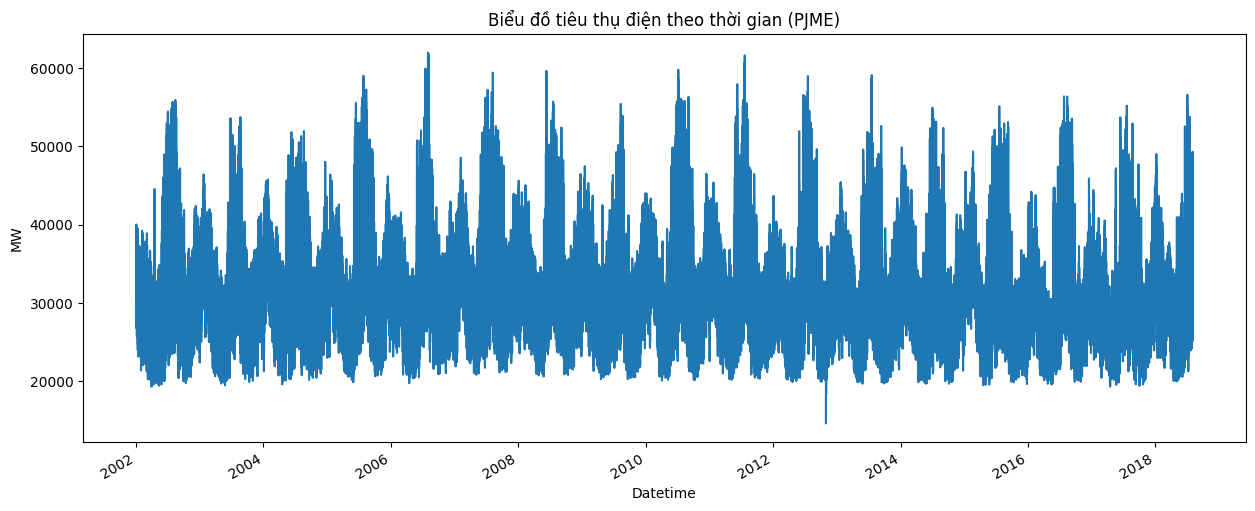

In [16]:
df = pd.read_csv('dataset/PJME_hourly.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')
df = df.sort_index()

print(df.head())

plt.figure(figsize=(15, 6))
df['PJME_MW'].plot()
plt.title('Biểu đồ tiêu thụ điện theo thời gian (PJME)')
plt.ylabel('MW')
plt.show()

## 2. Phân Tích Chu Kỳ (Seasonality Analysis)

Kiểm tra sự thay đổi của lượng điện tiêu thụ theo giờ trong ngày, ngày trong tuần và tháng trong năm.

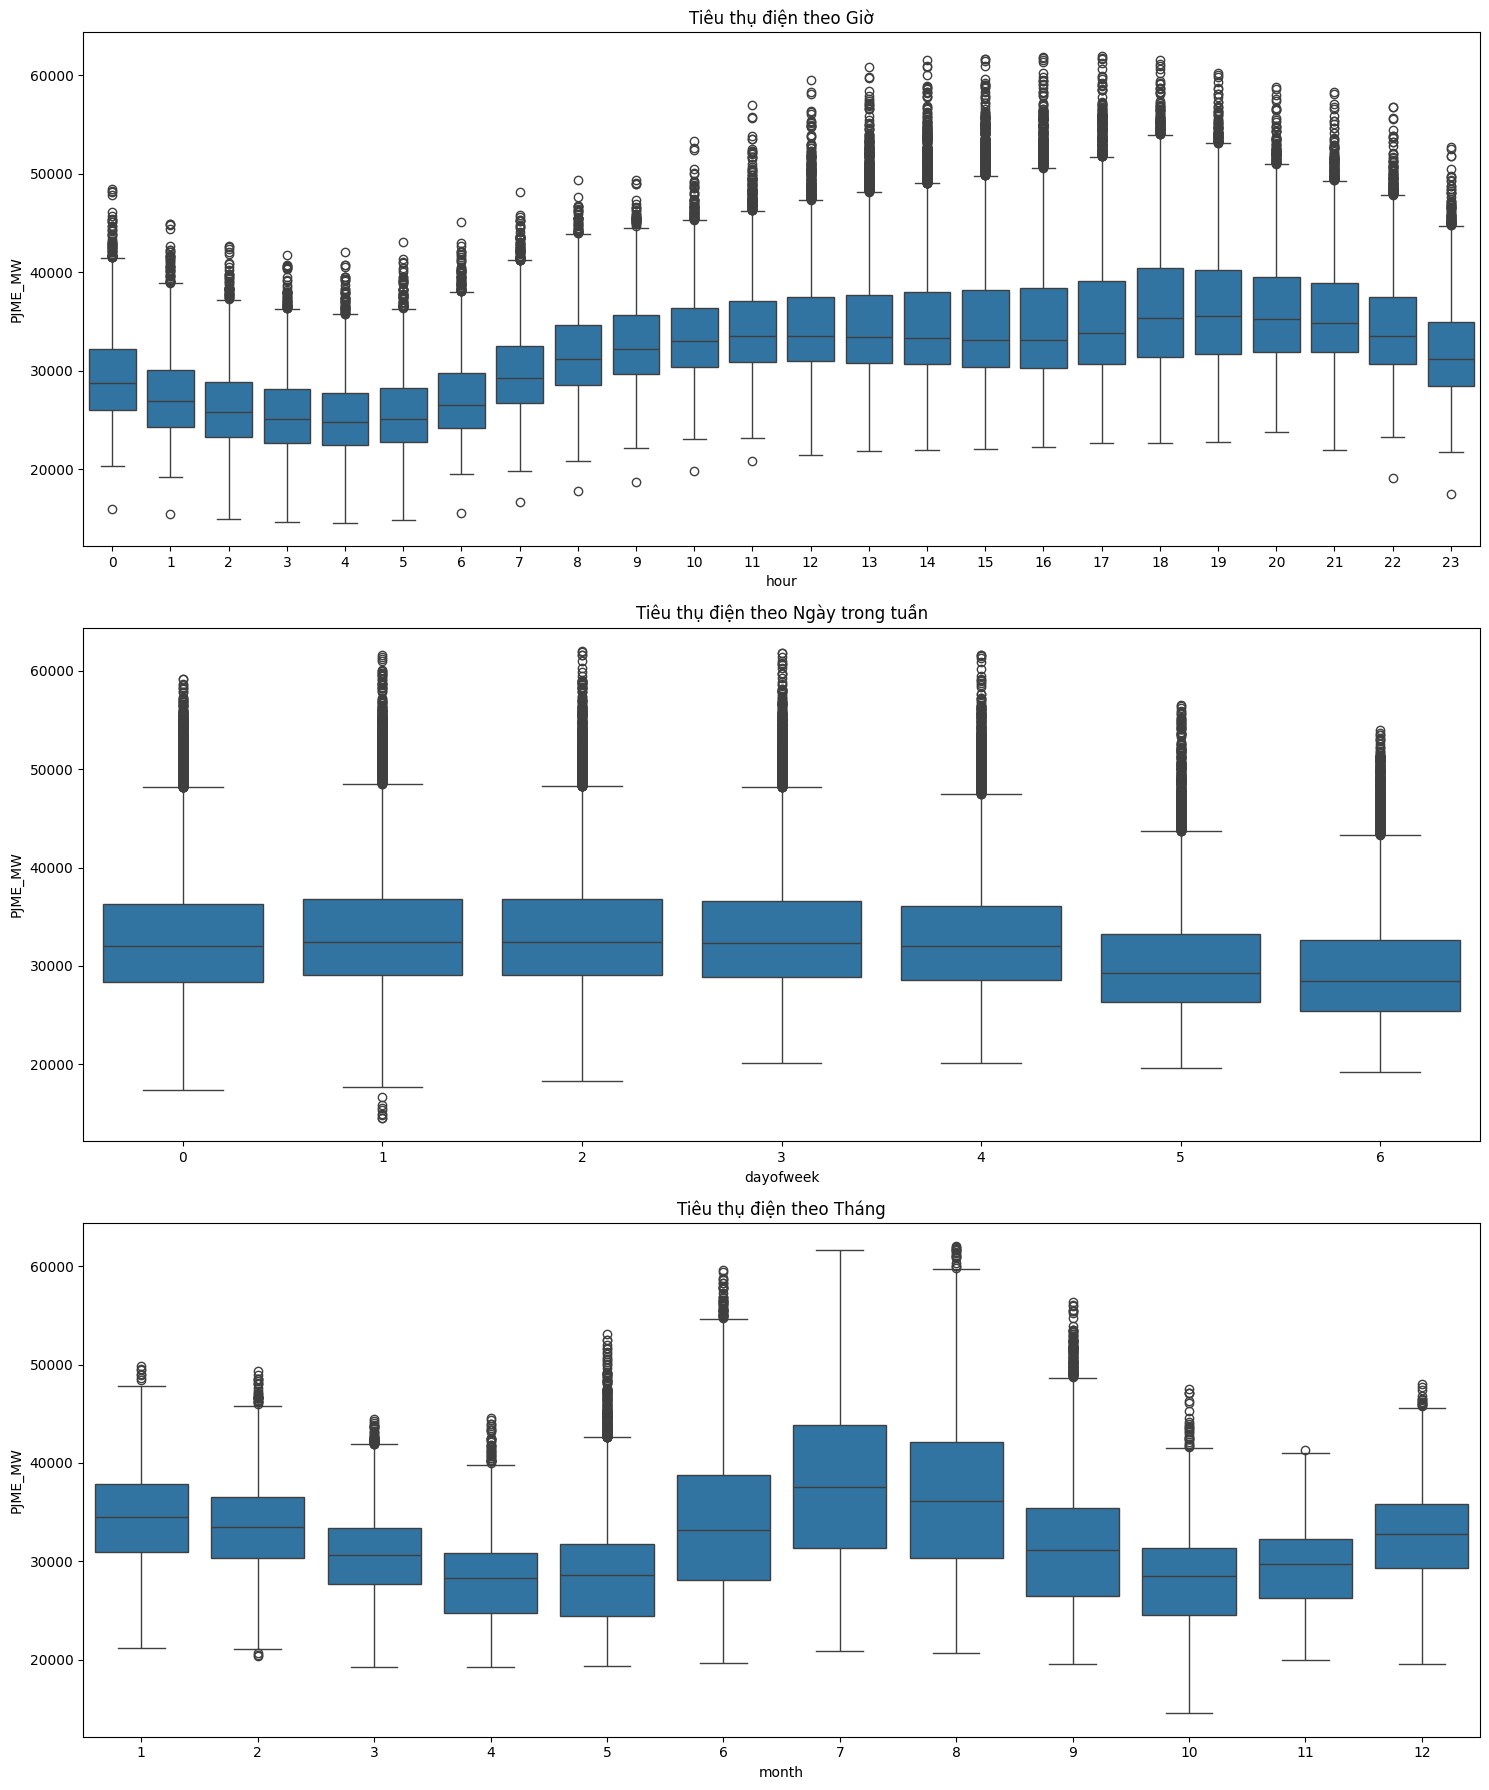

In [17]:
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month

fig, axes = plt.subplots(3, 1, figsize=(15, 18))
sns.boxplot(data=df, x='hour', y='PJME_MW', ax=axes[0])
axes[0].set_title('Tiêu thụ điện theo Giờ')

sns.boxplot(data=df, x='dayofweek', y='PJME_MW', ax=axes[1])
axes[1].set_title('Tiêu thụ điện theo Ngày trong tuần')

sns.boxplot(data=df, x='month', y='PJME_MW', ax=axes[2])
axes[2].set_title('Tiêu thụ điện theo Tháng')

plt.tight_layout()
plt.show()

## 3. Tiền Xử Lý Dữ Liệu (Preprocessing)

Chuẩn hóa dữ liệu về khoảng [0, 1] và tạo các chuỗi thời gian (sequences) với độ dài 24 giờ.

In [18]:
# Feature Engineering: Cyclical encoding
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 23)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 23)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

features = ['PJME_MW', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']
data = df[features].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length, 0]) # Target is only PJME_MW (index 0)
    return np.array(X), np.array(y)

SEQ_LENGTH = 24
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

X_train, y_train = create_sequences(train_data, SEQ_LENGTH)
X_test, y_test = create_sequences(test_data, SEQ_LENGTH)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (116268, 24, 5)
X_test shape: (29050, 24, 5)


## 4. Xây Dựng và Huấn Luyện Mô Hình LSTM

In [19]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(SEQ_LENGTH, 5)),
    Dropout(0.2),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.2),
    Dense(32),
    Dense(1)
])

# Custom optimizer with adjusted learning rate
optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='mean_squared_error')

# Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Bắt đầu huấn luyện...")
history = model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=100,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

Bắt đầu huấn luyện...
Epoch 1/100


/Users/tranbaonguyen/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1636/1636 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 0.0075 - val_loss: 7.0412e-04
Epoch 2/100
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 8.8674e-04 - val_loss: 4.7518e-04
Epoch 3/100
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 6.0346e-04 - val_loss: 4.3266e-04
Epoch 4/100
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 5.0003e-04 - val_loss: 0.0013
Epoch 5/100
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 5.0024e-04 - val_loss: 3.1017e-04
Epoch 6/100
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 3.7811e-04 - val_loss: 4.7806e-04
Epoch 7/100
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 3.5014e-04 - val_loss: 1.7872e-04
Epoch 8/100
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 2.8943e-04 - val_loss: 3.2775e-04
Epoch 9/100
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 2.6443e-04 - val_loss: 1.2223e-04
Epoch 10/100
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 2.0893e-04 - val_loss: 1.1906e-04
Epoch 11/100
1636/1636 ━━━━━━

## 5. Đánh Giá và Dự Báo

908/908 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
RMSE: 347.33
MAE: 260.34
RMSE on Peak-load (Top 10%): 536.41


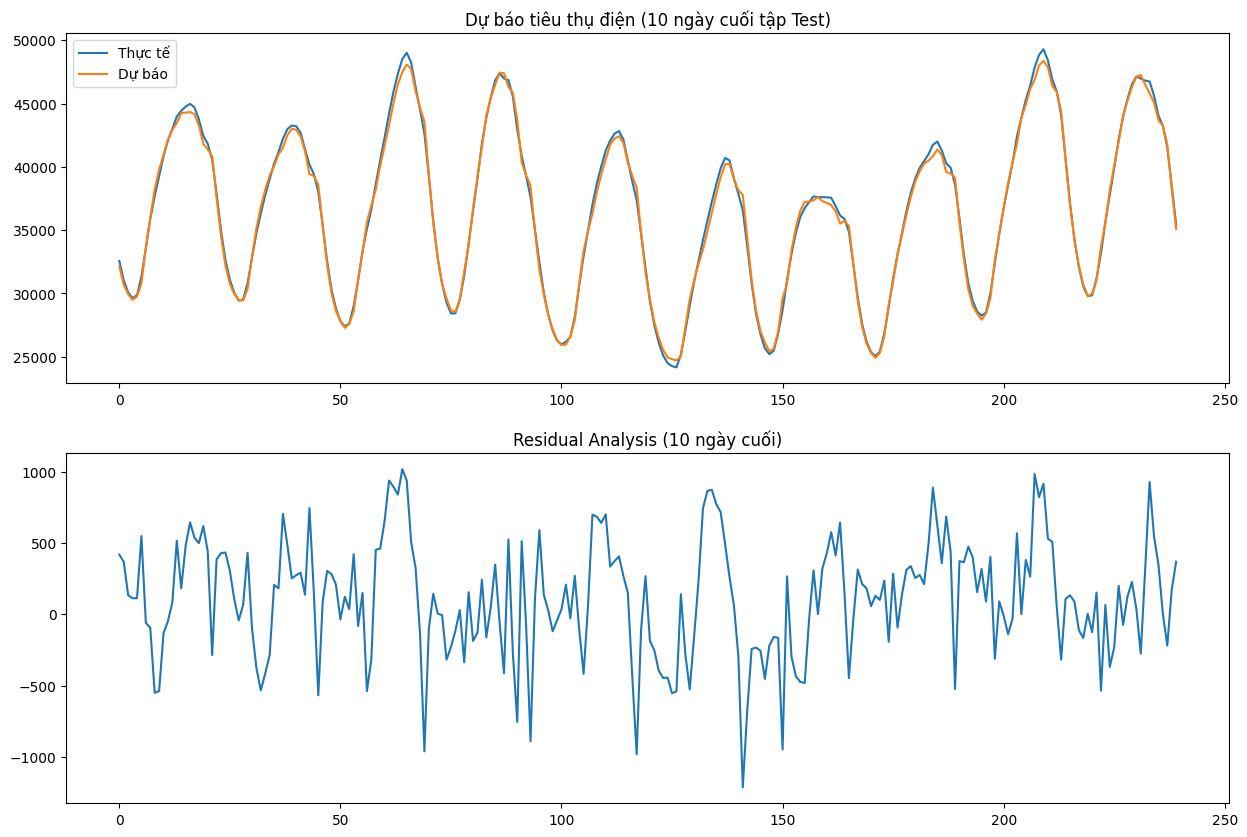

In [20]:
predictions = model.predict(X_test)

# Inverse transform only the MW column (index 0)
def inverse_transform_mw(data, scaler):
    padded = np.zeros((len(data), 5))
    padded[:, 0] = data.flatten()
    return scaler.inverse_transform(padded)[:, 0]

predictions = inverse_transform_mw(predictions, scaler)
y_test_unscaled = inverse_transform_mw(y_test, scaler)

rmse = np.sqrt(mean_squared_error(y_test_unscaled, predictions))
mae = mean_absolute_error(y_test_unscaled, predictions)
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

# Peak-load Evaluation (Top 10%)
threshold = np.percentile(y_test_unscaled, 90)
mask = y_test_unscaled >= threshold
rmse_peak = np.sqrt(mean_squared_error(y_test_unscaled[mask], predictions[mask]))
print(f"RMSE on Peak-load (Top 10%): {rmse_peak:.2f}")

plt.figure(figsize=(15, 10))

# Plot 1: Forecast
plt.subplot(2, 1, 1)
plt.plot(y_test_unscaled[-240:], label='Thực tế')
plt.plot(predictions[-240:], label='Dự báo')
plt.title('Dự báo tiêu thụ điện (10 ngày cuối tập Test)')
plt.legend()

# Plot 2: Residuals
plt.subplot(2, 1, 2)
residuals = y_test_unscaled - predictions
plt.plot(residuals[-240:])
plt.title('Residual Analysis (10 ngày cuối)')
plt.show()

## 6. Lưu Mô Hình

In [21]:
model.save('pjme_lstm_model.h5')
print("Đã lưu mô hình pjme_lstm_model.h5")

Đã lưu mô hình pjme_lstm_model.h5
